Install Libraries & Imports

In [19]:
# Install dependencies
!pip install transformers torch scikit-learn pandas matplotlib seaborn -q

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print(" All libraries imported")

 All libraries imported


Load Dataset

In [2]:
url = "https://raw.githubusercontent.com/t-davidson/hate-speech-and-offensive-language/master/data/labeled_data.csv"
df = pd.read_csv(url)


df = df[['tweet', 'class']].copy()
df.rename(columns={'class': 'label'}, inplace=True)  # 0=hate, 1=offensive, 2=neither

print(f" Dataset loaded: {df.shape[0]} tweets")
print("Class distribution:\n", df['label'].value_counts())

 Dataset loaded: 24783 tweets
Class distribution:
 label
1    19190
2     4163
0     1430
Name: count, dtype: int64


Text Cleaning

In [3]:

import re

def clean_tweet(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '@user', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_tweet'] = df['tweet'].apply(clean_tweet)

print("\n=== Example cleaned tweets ===")
for i in range(3):
    print(f"Original: {df['tweet'].iloc[i][:100]}...")
    print(f"Cleaned : {df['clean_tweet'].iloc[i]}\n")


=== Example cleaned tweets ===
Original: !!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man...
Cleaned : rt user as a woman you shouldnt complain about cleaning up your house amp as a man you should always take the trash out

Original: !!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!...
Cleaned : rt user boy dats coldtyga dwn bad for cuffin dat hoe in the st place

Original: !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a bitch and she start to cry? You...
Cleaned : rt user dawg rt user you ever fuck a bitch and she start to cry you be confused as shit



Train/Val/Test Split

In [18]:

X = df['clean_tweet']
y = df['label']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print("\nClass distribution in train set:\n", y_train.value_counts(normalize=True))

Train: 19826 | Val: 2478 | Test: 2479

Class distribution in train set:
 label
1    0.774337
2    0.167961
0    0.057702
Name: proportion, dtype: float64


Tokenizer & Custom Dataset

In [5]:

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = TweetDataset(X_train, y_train, tokenizer)
val_dataset   = TweetDataset(X_val,   y_val,   tokenizer)
test_dataset  = TweetDataset(X_test,  y_test,  tokenizer)

print(" Tokenized datasets created")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

 Tokenized datasets created


DataLoaders

In [17]:

BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f" DataLoaders ready (batch size = {BATCH_SIZE})")

 DataLoaders ready (batch size = 16)


Model, Weighted Loss & Optimizer

In [7]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=3
).to(device)


class_weights = compute_class_weight('balanced', classes=np.array([0,1,2]), y=y_train.values)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=len(train_loader)*4)

print(" DistilBERT model + weighted loss ready")

Using device: cuda


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 DistilBERT model + weighted loss ready


Training & Evaluation Functions + Training Loop

In [12]:

def train_epoch(model, data_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    for batch in tqdm(data_loader, desc="Training"):
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits, labels)

        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()

    return total_loss / len(data_loader), correct / len(data_loader.dataset)

def eval_epoch(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels)

            total_loss += loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(data_loader), all_preds, all_labels

EPOCHS = 4
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_preds, val_labels = eval_epoch(model, val_loader, criterion, device)
    val_acc = accuracy_score(val_labels, val_preds)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

Evaluating: 100%|██████████| 155/155 [00:10<00:00, 14.20it/s]


Epoch 1/4 | Train Loss: 0.1687 Acc: 0.9163 | Val Loss: 0.4555 Acc: 0.8688


Evaluating: 100%|██████████| 155/155 [00:10<00:00, 14.14it/s]


Epoch 2/4 | Train Loss: 0.1675 Acc: 0.9162 | Val Loss: 0.4555 Acc: 0.8688


Evaluating: 100%|██████████| 155/155 [00:10<00:00, 14.15it/s]


Epoch 3/4 | Train Loss: 0.1666 Acc: 0.9170 | Val Loss: 0.4555 Acc: 0.8688


Evaluating: 100%|██████████| 155/155 [00:10<00:00, 14.16it/s]

Epoch 4/4 | Train Loss: 0.1672 Acc: 0.9178 | Val Loss: 0.4555 Acc: 0.8688


Plot Training Curves

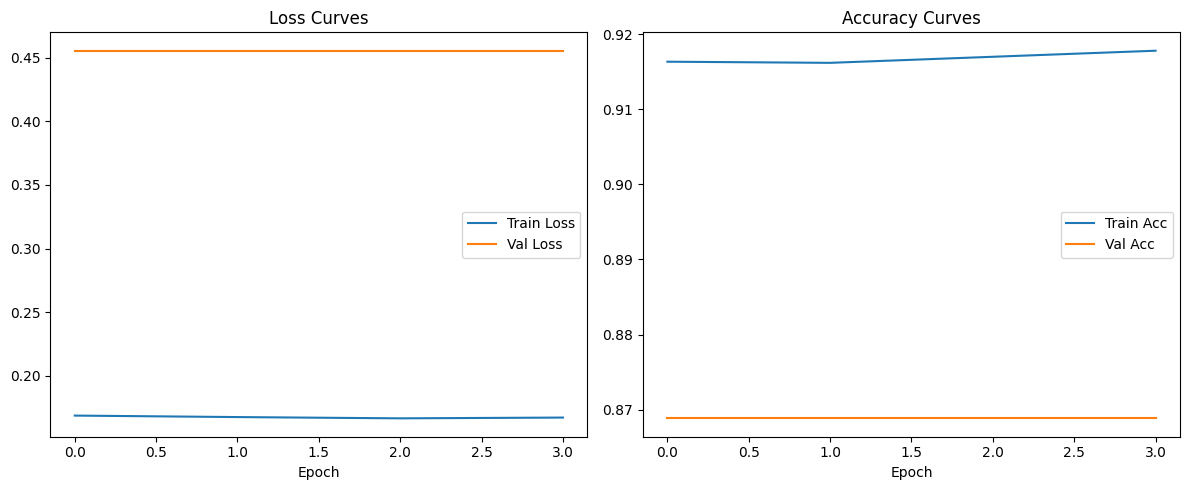

In [14]:

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

Final Test Evaluation & Confusion Matrix

Test Evaluation: 100%|██████████| 155/155 [00:11<00:00, 13.02it/s]



=== FINAL TEST RESULTS ===
               precision    recall  f1-score   support

     Hate (0)       0.31      0.67      0.43       143
Offensive (1)       0.97      0.87      0.92      1919
  Neither (2)       0.87      0.93      0.90       417

     accuracy                           0.87      2479
    macro avg       0.72      0.82      0.75      2479
 weighted avg       0.91      0.87      0.88      2479



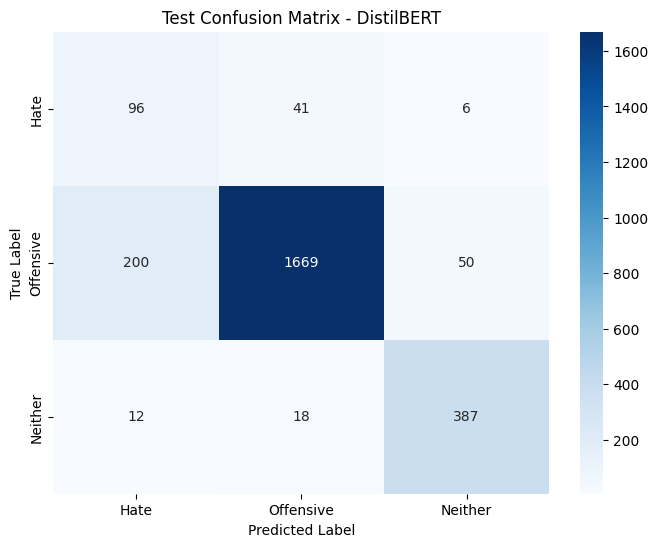

In [15]:

model.eval()
test_preds = []
test_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Test Evaluation"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

print("\n=== FINAL TEST RESULTS ===")
print(classification_report(test_labels, test_preds, target_names=['Hate (0)', 'Offensive (1)', 'Neither (2)']))

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Hate', 'Offensive', 'Neither'],
            yticklabels=['Hate', 'Offensive', 'Neither'])
plt.title('Test Confusion Matrix - DistilBERT')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Confidence Analysis


Threshold | Coverage (%) | Accuracy on covered posts
0.60     | 94.7%        | 0.887
0.70     | 89.8%        | 0.903
0.75     | 87.0%        | 0.911
0.80     | 83.8%        | 0.920
0.85     | 80.6%        | 0.929
0.90     | 76.4%        | 0.939
0.95     | 67.2%        | 0.971


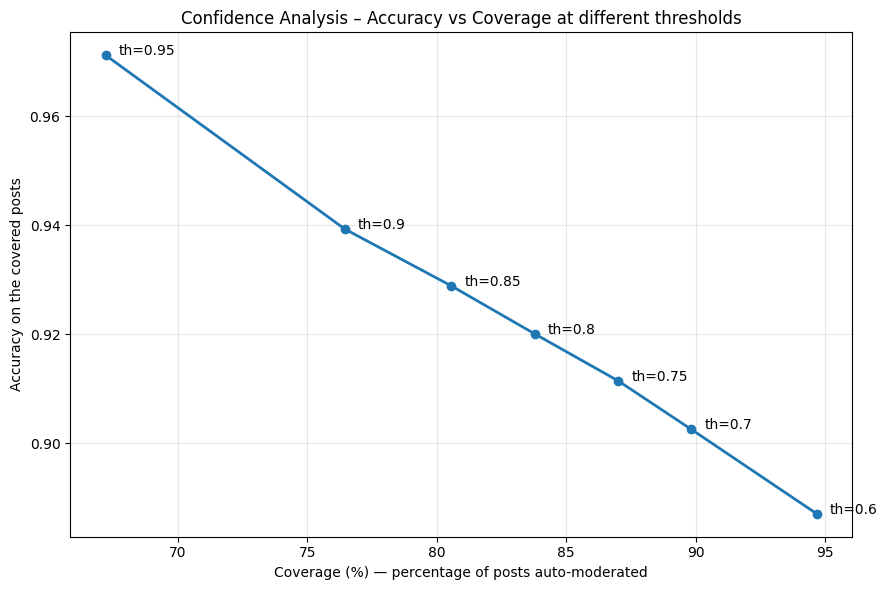

In [21]:

model.eval()
all_probs = []
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Collecting probabilities for confidence plot"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)
        max_probs, preds = torch.max(probs, dim=1)

        all_probs.extend(max_probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

# Calculating accuracy vs coverage at different thresholds
thresholds = [0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
accuracies = []
coverages = []

print("\nThreshold | Coverage (%) | Accuracy on covered posts")
for thresh in thresholds:
    mask = all_probs >= thresh
    if np.sum(mask) == 0:
        acc = 0
        cov = 0
    else:
        acc = accuracy_score(all_labels[mask], all_preds[mask])
        cov = np.mean(mask) * 100
    accuracies.append(acc)
    coverages.append(cov)
    print(f"{thresh:.2f}     | {cov:.1f}%        | {acc:.3f}")


plt.figure(figsize=(9,6))
plt.plot(coverages, accuracies, marker='o', linewidth=2)
plt.xlabel('Coverage (%) — percentage of posts auto-moderated')
plt.ylabel('Accuracy on the covered posts')
plt.title('Confidence Analysis – Accuracy vs Coverage at different thresholds')
plt.grid(True, alpha=0.3)


for i, thresh in enumerate(thresholds):
    plt.text(coverages[i] + 0.5, accuracies[i], f'th={thresh}', fontsize=10)

plt.tight_layout()
plt.show()

Save Model

In [16]:

torch.save(model.state_dict(), 'distilbert_hate_speech_model.pth')
print(" Model saved as 'distilbert_hate_speech_model.pth' (use in Part 5)")

 Model saved as 'distilbert_hate_speech_model.pth' (use in Part 5)
